In [7]:
from __future__ import annotations

from pathlib import Path
import json
from typing import Dict, List

import numpy as np
import pandas as pd
from IPython.display import display

# Root that contains editor/model/dataset/mc_all.json trees
RESULTS_ROOT = Path("/scratch/jq2uw/MME/instruct_vlm_edit/results/ee")

# Metrics we care about and their display labels (keep the order consistent)
METRIC_MAP: Dict[str, str] = {
    "reliability": "Acc",
    "text_generality": "T-Gen",
    "image_generality": "I-Gen",
    "coe_generality": "COE-Gen",
    "rationale_generality": "R-Gen",
    "loc_avg": "Loc",  # average of locality and hard_locality
    #"hm": "HM",
    "n_edits": "#Errors",
}

# Method metadata: (pretty label, uses external pretrain?)
METHOD_META = {
    "baseline": ("Baseline", False),
    "ft": ("FT", False),
    "ft_cot": ("FT-COT", False),
    # "ft_retrain": ("FT-Retrain", False),
    # "ft_retrain_cot": ("FT-Retrain-COT", False),
    "ike": ("IKE", True),
    "ike_cot": ("IKE-COT", False),
    # "ike_clip": ("IKE-CLIP", False),
    # "ike_tuple": ("IKE-Tuple", False),
    "ike_chain": ("ReasonEdit", False),
    "mend": ("MEND", True),
    "grace": ("GRACE", False),
    "balancedit": ("BalancEdit", False),
}

DATASET_LABELS = {
    "fvqa": "FVQA",
    "aokvqa": "A-OKVQA",
}

BACKBONE_LABELS = {
    "Qwen3-VL-8B-Instruct": "Qwen3-VL-8B",
    "Qwen3-VL-4B-Instruct": "Qwen3-VL-4B",
    "llava-1.5-7b-hf": "LLaVA-1.5-7B",
    "instructblip-vicuna-7b": "InstructBLIP-7B",
}

METHOD_ORDER: List[str] = list(METHOD_META.keys())
DATASET_ORDER: List[str] = ["fvqa", "aokvqa"]
BACKBONE_ORDER: List[str] = list(BACKBONE_LABELS.keys())


In [8]:
# Helpers for loading mc_all metrics and assembling the publication-style table

def _ordered_keys(present: List[str], preferred: List[str]) -> List[str]:
    present_set = list(present)
    ordered = [key for key in preferred if key in present_set]
    ordered += sorted(key for key in present_set if key not in preferred)
    return ordered


def collect_mc_rows(root: Path) -> pd.DataFrame:
    rows: List[Dict[str, object]] = []
    if not root.exists():
        raise FileNotFoundError(f"{root} was not found")

    for method_dir in sorted(root.iterdir()):
        if not method_dir.is_dir():
            continue
        method_key = method_dir.name.lower()
        if method_key not in METHOD_META:
            continue
        method_label, _needs_pretrain = METHOD_META[method_key]

        for model_dir in sorted(method_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            model_key = model_dir.name
            backbone_label = BACKBONE_LABELS.get(model_key, model_key)

            for dataset_dir in sorted(model_dir.iterdir()):
                if not dataset_dir.is_dir():
                    continue
                metrics_path = dataset_dir / "mc_all.json"
                if not metrics_path.exists():
                    continue
                try:
                    text = metrics_path.read_text().strip()
                    if not text:
                        continue
                    try:
                        # all-at-once: single JSON object (can be pretty-printed with newlines)
                        metrics = json.loads(text)
                    except Exception:
                        # sequential: JSONL, compute mean of all entries
                        all_metrics = [json.loads(ln) for ln in text.splitlines() if ln.strip()]
                        if not all_metrics:
                            continue
                        # Average numeric values across all entries
                        metrics = {}
                        for key in all_metrics[0]:
                            vals = [m.get(key) for m in all_metrics if m.get(key) is not None]
                            if vals and all(isinstance(v, (int, float)) for v in vals):
                                metrics[key] = sum(vals) / len(vals)
                            else:
                                metrics[key] = all_metrics[-1].get(key)  # non-numeric: use last
                except Exception as exc:  # pragma: no cover - diagnostic aid only
                    print(f"Skipping {metrics_path}: {exc}")
                    continue

                # Compute loc_avg as average of locality and hard_locality
                loc = metrics.get("locality")
                hard_loc = metrics.get("hard_locality")
                if loc is not None and hard_loc is not None:
                    loc_avg = (loc + hard_loc) / 2
                elif loc is not None:
                    loc_avg = loc
                elif hard_loc is not None:
                    loc_avg = hard_loc
                else:
                    loc_avg = None
                metrics["loc_avg"] = loc_avg

                row: Dict[str, object] = {
                    "method_key": method_key,
                    "method": method_label,
                    "dataset_key": dataset_dir.name,
                    "dataset": DATASET_LABELS.get(dataset_dir.name, dataset_dir.name),
                    "model_key": model_key,
                    "backbone": backbone_label,
                    "file": str(metrics_path),
                    "n_edits": metrics.get("n_edits"),
                }
                for metric_key in METRIC_MAP:
                    row[metric_key] = metrics.get(metric_key)
                rows.append(row)

    return pd.DataFrame(rows)


def build_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    df = df.copy()
    dataset_order = _ordered_keys(df["dataset_key"].unique().tolist(), DATASET_ORDER)
    method_order = _ordered_keys(df["method_key"].unique().tolist(), METHOD_ORDER)
    backbone_order = _ordered_keys(df["model_key"].unique().tolist(), BACKBONE_ORDER)

    dataset_labels = [DATASET_LABELS.get(key, key) for key in dataset_order]
    method_labels = [METHOD_META[key][0] for key in method_order]
    backbone_labels = [BACKBONE_LABELS.get(key, key) for key in backbone_order]

    df["dataset"] = pd.Categorical(df["dataset"], categories=dataset_labels, ordered=True)
    df["method"] = pd.Categorical(df["method"], categories=method_labels, ordered=True)
    df["backbone"] = pd.Categorical(df["backbone"], categories=backbone_labels, ordered=True)

    metric_keys = list(METRIC_MAP.keys())
    summary = (
        df.sort_values(["dataset", "method", "backbone"], kind="stable")
        .set_index(["dataset", "method", "backbone"])[metric_keys]
        .unstack("backbone")
    )

    summary = summary.swaplevel(0, 1, axis=1).rename(columns=METRIC_MAP, level=1)
    metric_labels = list(METRIC_MAP.values())
    full_columns = pd.MultiIndex.from_product(
        [backbone_labels, metric_labels], names=["Backbone", "Metric"]
    )
    summary = summary.reindex(columns=full_columns)
    summary.index.names = ["Dataset", "Method"]
    return summary


def style_summary(table: pd.DataFrame):
    if table.empty:
        return table

    return (
        table.style.format("{:.2f}")
        .set_properties(**{"text-align": "center"})
        .set_table_styles(
            [
                {"selector": "th.col_heading", "props": "text-align: center;"},
                {"selector": "th.row_heading", "props": "text-align: left;"},
            ],
            overwrite=False,
        )
    )


## Load mc_all metrics

In [9]:
mc_df = collect_mc_rows(RESULTS_ROOT)
print(f"Loaded {len(mc_df)} result rows from {RESULTS_ROOT}")
if not mc_df.empty:
    display(mc_df.sort_values(["dataset", "method", "backbone"]).reset_index(drop=True))
else:
    display(mc_df)

Loaded 56 result rows from /scratch/jq2uw/MME/instruct_vlm_edit/results/ee


,method_key,method,dataset_key,dataset,model_key,backbone,file,n_edits,reliability,text_generality,image_generality,coe_generality,rationale_generality,loc_avg
0,balancedit,BalancEdit,aokvqa,A-OKVQA,instructblip-vicuna-7b,InstructBLIP-7B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,40.0,0.700862,0.529310,0.426480,0.397850,0.500261,0.683642
1,balancedit,BalancEdit,aokvqa,A-OKVQA,llava-1.5-7b-hf,LLaVA-1.5-7B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,40.0,0.733333,0.687619,0.278504,0.324397,0.490859,0.600305
2,balancedit,BalancEdit,aokvqa,A-OKVQA,Qwen3-VL-4B-Instruct,Qwen3-VL-4B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,40.0,0.520000,0.492000,0.231330,0.242868,0.429440,0.529270
3,balancedit,BalancEdit,aokvqa,A-OKVQA,Qwen3-VL-8B-Instruct,Qwen3-VL-8B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,40.0,0.572500,0.547167,0.364047,0.462016,0.440067,0.469801
4,baseline,Baseline,aokvqa,A-OKVQA,instructblip-vicuna-7b,InstructBLIP-7B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,5954.0,0.000000,0.137555,0.114197,NaN,0.626684,1.000000
5,baseline,Baseline,aokvqa,A-OKVQA,llava-1.5-7b-hf,LLaVA-1.5-7B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,7197.0,0.000000,0.116021,0.104843,NaN,0.611746,1.000000
6,baseline,Baseline,aokvqa,A-OKVQA,Qwen3-VL-4B-Instruct,Qwen3-VL-4B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,5188.0,0.000000,0.144661,0.152958,NaN,0.583271,1.000000
7,baseline,Baseline,aokvqa,A-OKVQA,Qwen3-VL-8B-Instruct,Qwen3-VL-8B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,3889.0,0.000000,0.121959,0.110808,NaN,0.580840,1.000000
8,ft,FT,aokvqa,A-OKVQA,instructblip-vicuna-7b,InstructBLIP-7B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,40.0,0.605172,0.517931,0.526989,0.573657,0.344365,0.427292
9,ft,FT,aokvqa,A-OKVQA,llava-1.5-7b-hf,LLaVA-1.5-7B,/scratch/jq2uw/MME/instruct_vlm_edit/results/e...,40.0,0.611207,0.570690,0.558152,0.554796,0.349074,0.397253


## Build publication table

In [10]:
summary_table = build_summary_table(mc_df)
if summary_table.empty:
    print("No mc_all metrics were found under the configured RESULTS_ROOT.")
else:
    display(style_summary(summary_table))
    flat = summary_table.copy()
    flat.columns = [f"{backbone}_{metric}" for backbone, metric in flat.columns]
    output_csv = RESULTS_ROOT / "ee_summary_table.csv"
    flat.to_csv(output_csv)
    print(f"Saved CSV to {output_csv}")

Saved CSV to /scratch/jq2uw/MME/instruct_vlm_edit/results/ee/ee_summary_table.csv


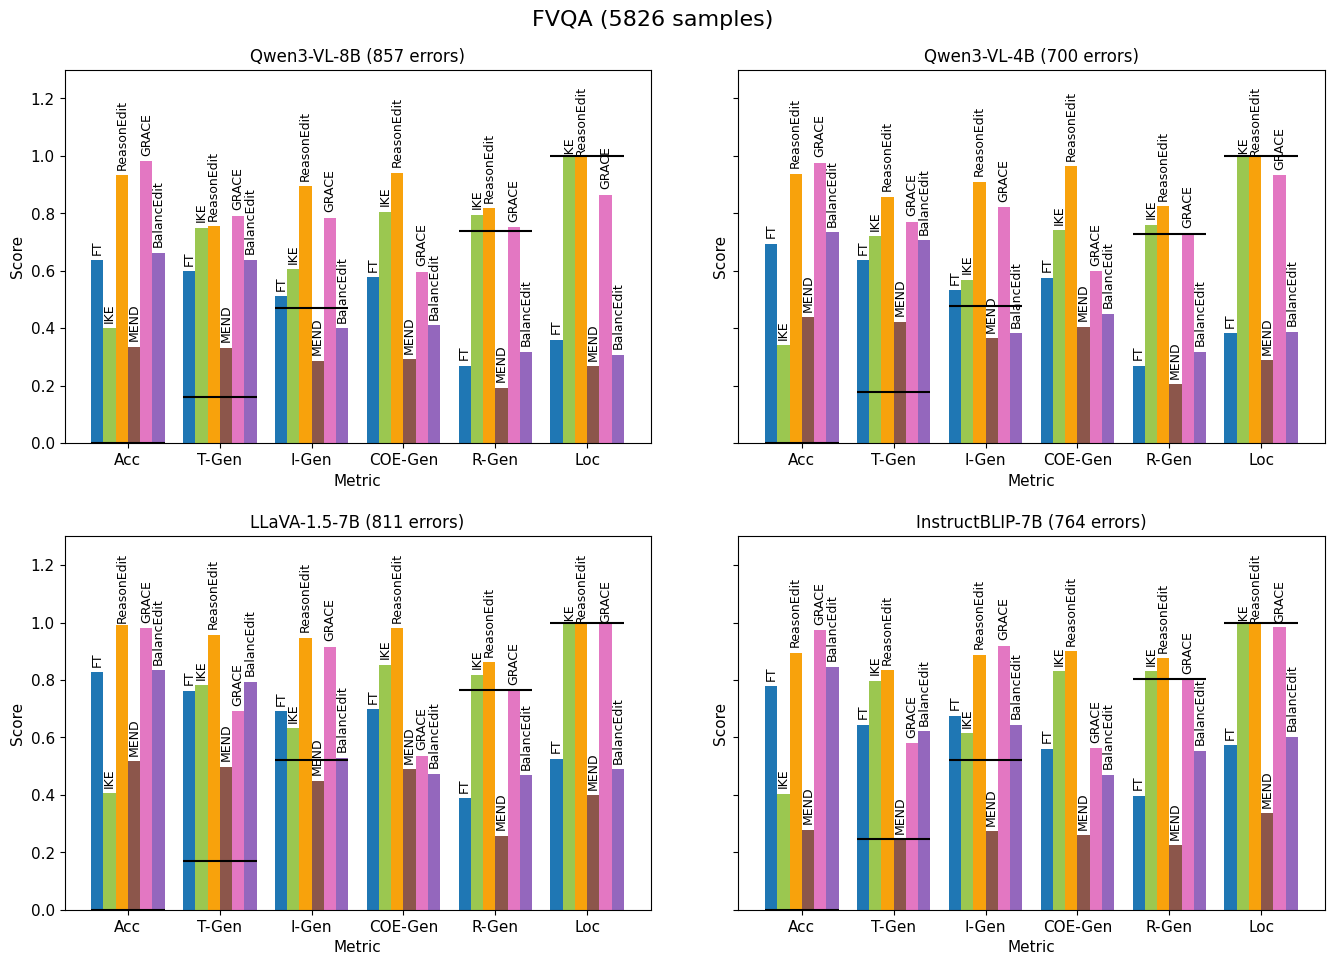

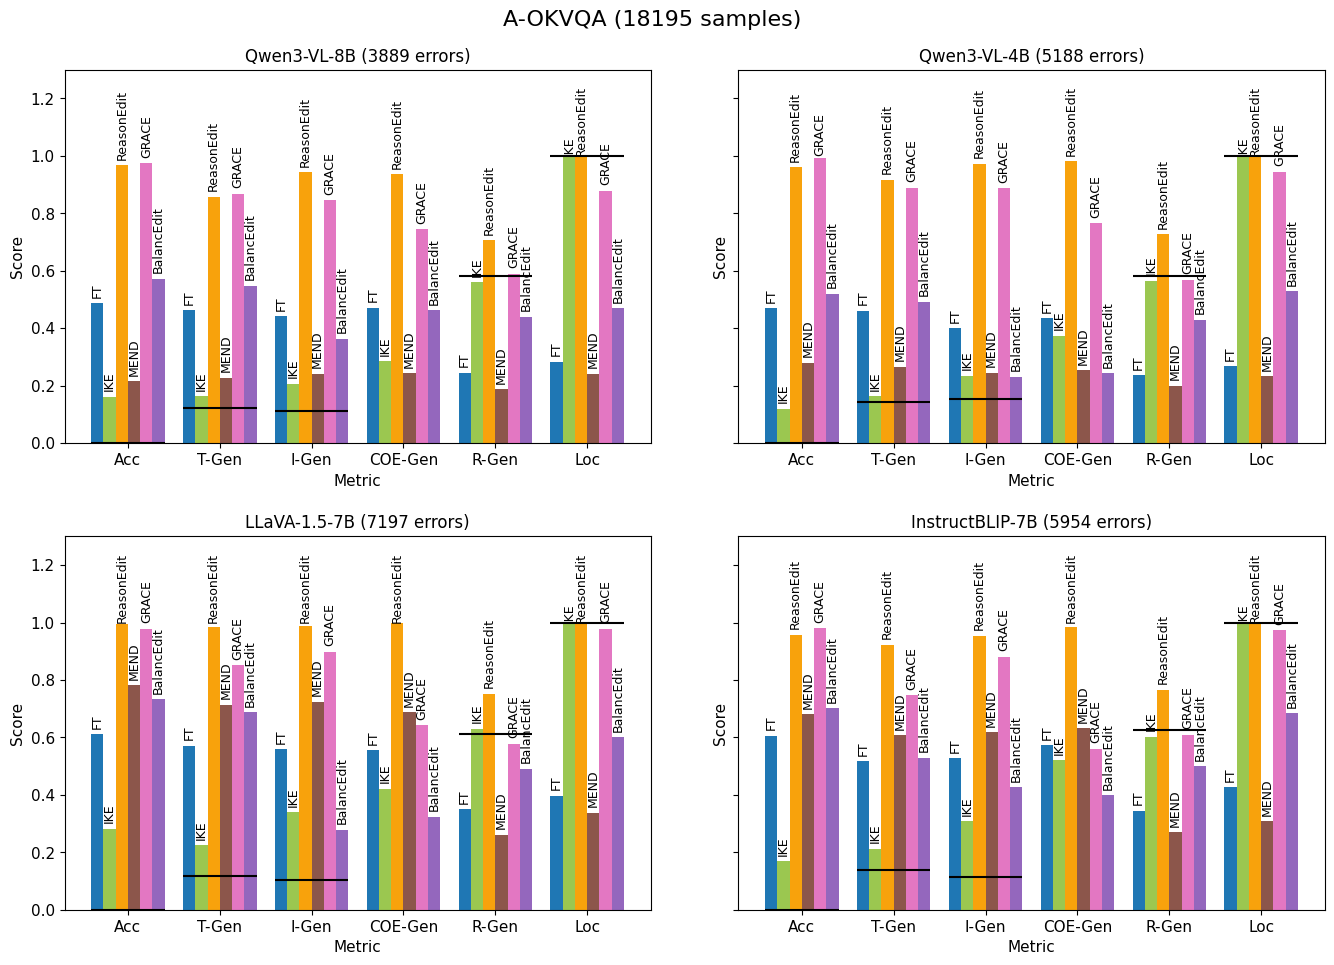

In [11]:
# Bar plots of metric scores grouped by dataset, backbone (VLM), and editor
import matplotlib.pyplot as plt
import numpy as np

if mc_df.empty:
    print("mc_df is empty; nothing to plot.")
else:
    # Long-form table: one row per (dataset, backbone, editor, metric)
    metric_keys = [k for k in METRIC_MAP.keys() if k != "n_edits"]  # drop count metric
    plot_df = mc_df.melt(
        id_vars=["dataset_key", "dataset", "model_key", "backbone", "method_key", "method"],
        value_vars=metric_keys,
        var_name="metric_key",
        value_name="score",
    )
    plot_df["Metric"] = plot_df["metric_key"].map(METRIC_MAP)

    # Consistent ordering
    dataset_order = _ordered_keys(plot_df["dataset_key"].unique().tolist(), DATASET_ORDER)
    backbone_order = _ordered_keys(plot_df["model_key"].unique().tolist(), BACKBONE_ORDER)
    method_order = _ordered_keys(plot_df["method_key"].unique().tolist(), METHOD_ORDER)

    plot_df["Dataset"] = pd.Categorical(
        plot_df["dataset"],
        categories=[DATASET_LABELS.get(k, k) for k in dataset_order],
        ordered=True,
    )
    plot_df["Backbone"] = pd.Categorical(
        plot_df["backbone"],
        categories=[BACKBONE_LABELS.get(k, k) for k in backbone_order],
        ordered=True,
    )
    plot_df["Editor"] = pd.Categorical(
        plot_df["method"],
        categories=[METHOD_META[k][0] for k in method_order],
        ordered=True,
    )
    plot_df["Metric"] = pd.Categorical(
        plot_df["Metric"],
        categories=[METRIC_MAP[k] for k in metric_keys],
        ordered=True,
    )

    metric_labels = [METRIC_MAP[k] for k in metric_keys]
    
    # Define consistent colors for each editor
    # Keys must match the pretty labels in METHOD_META (e.g., "FT-Retrain").
    #
    # FT family  -> distinctive cold colors (blue/green variants)
    # IKE family -> distinctive warm colors (red/orange variants)
    editor_colors = {
        # Baseline
        "Baseline": "black",

        # FT family (cold colors)
        "FT": "#1f77b4",            # blue
        "FT-COT": "#2ca02c",        # green
        "FT-Retrain": "#17becf",    # cyan/teal
        "FT-Retrain-COT": "#1f9e89",# teal-green

        # IKE family (warm colors)
        "IKE": "#9BC750",           # green
        "IKE-COT": "#d62728",       # red
        "IKE-CLIP": "#479A5F",      # green
        # "IKE-Tuple": "#F8A20C",     # light orange
        "ReasonEdit": "#F8A20C",     # light orange

        # Other editors (remaining distinctive colors)
        "MEND": "#8c564b",          # brown
        "GRACE": "#e377c2",         # pink
        "BalancEdit": "#9467bd",    # purple
    }
    
    # Dataset sample counts
    dataset_samples = {
        "FVQA": 5826,
        "A-OKVQA": 18195,
    }

    # One figure per dataset, each with 2x2 panels for the four VLMs
    for dataset_cat in plot_df["Dataset"].cat.categories:
        ds_df = plot_df[plot_df["Dataset"] == dataset_cat]
        if ds_df.empty:
            continue

        # Build title with dataset sample count only (errors shown per-model in subpanels)
        title = str(dataset_cat)
        if dataset_cat in dataset_samples:
            title += f" ({dataset_samples[dataset_cat]} samples)"
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
        fig.suptitle(title, fontsize=16, y=0.98)
        plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.08, wspace=0.15, hspace=0.25)

        backbone_cats = plot_df["Backbone"].cat.categories
        editor_cats = plot_df["Editor"].cat.categories

        for ax, backbone_cat in zip(axes.flatten(), backbone_cats):
            sub_df = ds_df[ds_df["Backbone"] == backbone_cat]
            if sub_df.empty:
                ax.axis("off")
                continue

            # Get n_edits from baseline for this backbone+dataset (total errors)
            backbone_key = sub_df["model_key"].iloc[0]
            dataset_key = sub_df["dataset_key"].iloc[0]
            n_edits_row = mc_df[
                (mc_df["model_key"] == backbone_key) & 
                (mc_df["dataset_key"] == dataset_key) & 
                (mc_df["method_key"] == "baseline")
            ]
            n_edits = n_edits_row["n_edits"].iloc[0] if not n_edits_row.empty and not pd.isna(n_edits_row["n_edits"].iloc[0]) else None

            # Get all editors present for this backbone
            editors = [e for e in editor_cats if (sub_df["Editor"] == e).any()]
            if not editors:
                ax.axis("off")
                continue

            # Separate baseline and IKE-COT (horizontal lines) from other editors (bars)
            line_editors = ["Baseline", "IKE-COT"]
            other_editors = [e for e in editors if e not in line_editors]
            
            # Plot baseline and IKE-COT as horizontal lines
            for line_editor in line_editors:
                if line_editor in editors:
                    for m_idx, metric in enumerate(metric_labels):
                        m_df = sub_df[sub_df["Metric"] == metric]
                        line_row = m_df[m_df["Editor"] == line_editor]
                        if not line_row.empty:
                            line_score = line_row["score"].iloc[0]
                            if not pd.isna(line_score):
                                ax.hlines(
                                    y=line_score,
                                    xmin=m_idx - 0.4,
                                    xmax=m_idx + 0.4,
                                    color=editor_colors.get(line_editor, "black"),
                                    linewidth=1.5,
                                )

            # Plot other editors as bars
            if other_editors:
                bar_width = 0.8 / len(other_editors)
                
                for m_idx, metric in enumerate(metric_labels):
                    m_df = sub_df[sub_df["Metric"] == metric]
                    for e_idx, editor in enumerate(other_editors):
                        row = m_df[m_df["Editor"] == editor]
                        if row.empty:
                            continue
                        score = row["score"].iloc[0]
                        if pd.isna(score):
                            continue
                        x = m_idx + (e_idx - (len(other_editors) - 1) / 2) * bar_width
                        color = editor_colors.get(editor, None)
                        ax.bar(
                            x,
                            score,
                            width=bar_width,
                            color=color,
                        )
                        # Label editor name on top of each bar
                        ax.text(
                            x,
                            min(score + 0.02, 1.0),
                            editor,
                            ha="center",
                            va="bottom",
                            rotation=90,
                            fontsize=9,
                        )

            # Build title with n_edits
            title = str(backbone_cat)
            if n_edits is not None:
                title += f" ({int(n_edits)} errors)"
            ax.set_title(title, fontsize=12)
            ax.set_xticks(range(len(metric_labels)))
            ax.set_xticklabels(metric_labels, fontsize=11)
            ax.set_xlabel("Metric", fontsize=11)
            ax.set_ylabel("Score", fontsize=11)
            ax.tick_params(axis='y', labelsize=11)
            ax.set_ylim(0, 1.3)

        plt.show()


In [12]:
## Collect editk results (mc_all_editk.json)
# editk results structure: {B, k_values, n_edits, editor, k1: {mean, std, ...}, k5: {...}, k10: {...}}

EDITK_ROOT = Path("/scratch/jq2uw/MME/instruct_vlm_edit/results/editk")

def collect_editk_rows(root: Path) -> pd.DataFrame:
    """Collect editk metrics from mc_all_editk.json files."""
    rows: List[Dict[str, object]] = []
    if not root.exists():
        raise FileNotFoundError(f"{root} was not found")

    for method_dir in sorted(root.iterdir()):
        if not method_dir.is_dir():
            continue
        method_key = method_dir.name.lower()
        if method_key not in METHOD_META:
            continue
        method_label, _needs_pretrain = METHOD_META[method_key]

        for model_dir in sorted(method_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            model_key = model_dir.name
            backbone_label = BACKBONE_LABELS.get(model_key, model_key)

            for dataset_dir in sorted(model_dir.iterdir()):
                if not dataset_dir.is_dir():
                    continue
                # Find editk files: mc_all_editk.json or mc_all_sub*_editk.json
                editk_files = list(dataset_dir.glob("mc_all*_editk.json"))
                if not editk_files:
                    continue
                # Use the most recent file if multiple exist
                metrics_path = max(editk_files, key=lambda p: p.stat().st_mtime)
                try:
                    text = metrics_path.read_text().strip()
                    if not text:
                        continue
                    metrics = json.loads(text)
                except Exception as exc:
                    print(f"Skipping {metrics_path}: {exc}")
                    continue

                row: Dict[str, object] = {
                    "method_key": method_key,
                    "method": method_label,
                    "dataset_key": dataset_dir.name,
                    "dataset": DATASET_LABELS.get(dataset_dir.name, dataset_dir.name),
                    "model_key": model_key,
                    "backbone": backbone_label,
                    "file": str(metrics_path),
                    "n_edits": metrics.get("n_edits"),
                    "B": metrics.get("B"),
                }
                # Extract k1, k5, k10 mean/std
                for k in metrics.get("k_values", [1, 5, 10]):
                    k_data = metrics.get(f"k{k}", {})
                    row[f"k{k}_mean"] = k_data.get("mean")
                    row[f"k{k}_std"] = k_data.get("std")
                rows.append(row)

    return pd.DataFrame(rows)

# Load editk results
editk_df = collect_editk_rows(EDITK_ROOT)
print(f"Loaded {len(editk_df)} editk result rows from {EDITK_ROOT}")
if not editk_df.empty:
    # Format mean (std) with 4 decimal places
    df_display = editk_df.sort_values(["dataset", "method", "backbone"]).reset_index(drop=True).copy()
    for k in [1, 5, 10]:
        mean_col, std_col = f"k{k}_mean", f"k{k}_std"
        if mean_col in df_display.columns and std_col in df_display.columns:
            df_display[f"k={k}"] = df_display.apply(
                lambda r: f"{r[mean_col]:.3f} ({r[std_col]:.3f})" if pd.notna(r[mean_col]) else "", axis=1
            )
    display_cols = ["method", "dataset", "backbone", "n_edits", "B", "k=1", "k=5", "k=10"]
    display_cols = [c for c in display_cols if c in df_display.columns]
    display(df_display[display_cols])
else:
    print("No editk results found yet. Available methods will appear as they complete.")


Loaded 22 editk result rows from /scratch/jq2uw/MME/instruct_vlm_edit/results/editk


,method,dataset,backbone,n_edits,B,k=1,k=5,k=10
0,FT,A-OKVQA,InstructBLIP-7B,1629,10,0.120 (0.043),0.198 (0.021),0.210 (0.014)
1,FT,A-OKVQA,LLaVA-1.5-7B,1979,10,0.180 (0.035),0.225 (0.012),0.230 (0.013)
2,FT,A-OKVQA,Qwen3-VL-4B,1415,10,0.187 (0.016),0.237 (0.014),0.237 (0.008)
3,FT,A-OKVQA,Qwen3-VL-8B,1967,10,0.245 (0.019),0.279 (0.015),0.271 (0.010)
4,IKE,A-OKVQA,Qwen3-VL-4B,1415,10,0.138 (0.007),0.156 (0.011),0.156 (0.009)
5,IKE,A-OKVQA,Qwen3-VL-8B,1967,10,0.206 (0.040),0.304 (0.018),0.306 (0.015)
6,BalancEdit,FVQA,InstructBLIP-7B,764,10,0.014 (0.003),0.040 (0.064),0.031 (0.010)
7,BalancEdit,FVQA,LLaVA-1.5-7B,811,10,0.009 (0.005),0.032 (0.048),0.045 (0.046)
8,BalancEdit,FVQA,Qwen3-VL-4B,700,10,0.179 (0.030),0.026 (0.017),0.023 (0.005)
9,BalancEdit,FVQA,Qwen3-VL-8B,857,10,0.172 (0.029),0.009 (0.005),0.025 (0.018)
